In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [17]:
filepath = '/content/heart.csv'
df = pd.read_csv(filepath)

In [18]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [19]:
df.shape

(918, 12)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [21]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
data = df.drop_duplicates()
data.shape

(918, 12)

In [24]:
chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

chol_zero

np.int64(172)

In [25]:
bp_zero

np.int64(1)

In [26]:
df[["Cholesterol","RestingBP"]].describe()

chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()

bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)

df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

df["Cholesterol"] = df["Cholesterol"].round(2)

df["RestingBP"] = df["RestingBP"].round(2)

df[["Cholesterol","RestingBP"]].describe()

,Cholesterol,RestingBP
count,918.000000,918.000000
mean,244.636253,132.540893
std,53.318029,17.989932
min,85.000000,80.000000
25%,214.000000,120.000000
50%,244.640000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


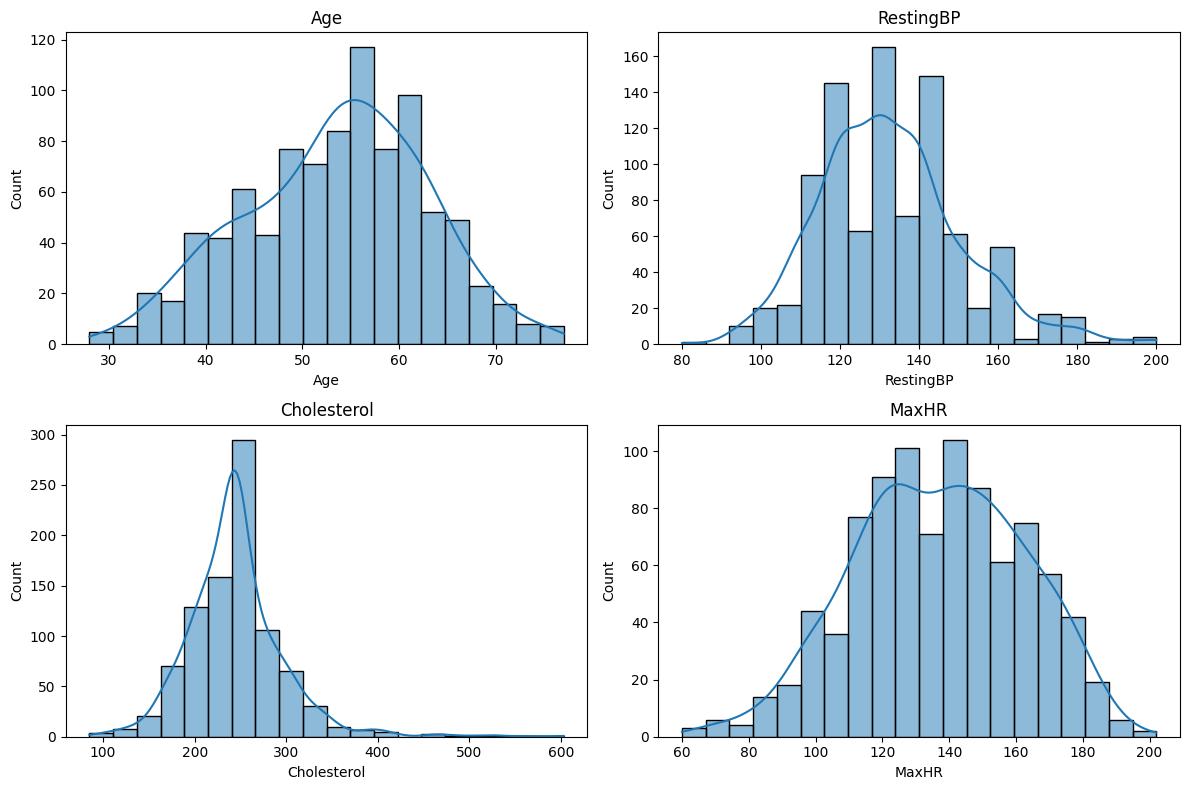

In [27]:
def plot_histograms():

    columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(12,8))

    for i, col in enumerate(columns,1):

        plt.subplot(2,2,i)

        sns.histplot(df[col], bins=20, kde=True)

        plt.title(col)

    plt.tight_layout()

    plt.show()

plot_histograms()

In [29]:
numerical = df.select_dtypes(include = np.number)
categorical = df.select_dtypes(exclude = np.number)

numerical.columns.tolist()

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease']

In [31]:
categorical.columns.tolist()

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [32]:
df_encoded = pd.get_dummies(df)
df_encoded.shape

(918, 21)

In [34]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [35]:
df_encoded.shape

(918, 21)

In [36]:
df_encoded.columns.tolist()

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']